In [1]:
!pip install -q python-igraph scikit-learn ripser persim openTSNE GraphRicciCurvature

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 13.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [2]:
import torch
from torch.utils.data import Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Define the transformation pipeline:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize the image
    transforms.Lambda(lambda x: x.view(-1))           # Flatten into a 784-dim vector
])

# Load the training set (set download=True if running for the first time)
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Get indices for images where the label is 1
indices = (mnist_train.targets == 1).nonzero().squeeze()

# Create a subset containing only the '1's
mnist_train_ones = Subset(mnist_train, indices)

print(f"Total number of '1' images in the training set: {len(mnist_train_ones)}")

# Stack all 784-dim vectors from the filtered dataset
all_vectors = torch.stack([img for img, _ in mnist_train_ones])
unique_vectors = torch.unique(all_vectors, dim=0)

print(f"Total images in mnist_train_ones: {all_vectors.shape[0]}")
print(f"Unique images: {unique_vectors.shape[0]}")

if all_vectors.shape[0] == unique_vectors.shape[0]:
    print("All 784-dimensional vectors are unique.")
else:
    print("There are duplicates in the 784-dimensional vectors.")

vectors_np = unique_vectors.numpy()

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 613kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.30MB/s]


Total number of '1' images in the training set: 6742
Total images in mnist_train_ones: 6742
Unique images: 6726
There are duplicates in the 784-dimensional vectors.


In [3]:
import numpy as np


'''
not quite an r-net because there is an additional consideration that no landmark is closer to any other landmark than another parameter.
'''
def farthest_first_landmarks(vectors, max_landmarks, max_radius=None, random_state=None):
    """
    Select up to `max_landmarks` landmarks by farthest-first traversal,
    stopping early if the farthest candidate is closer than `max_radius`.

    Parameters
    ----------
    vectors : np.ndarray, shape (n_samples, n_features)
        Data points.
    max_landmarks : int
        Maximum number of landmarks to select.
    max_radius : float or None
        If the current farthest‐first distance is ≤ max_radius, stop early.
    random_state : int or np.random.Generator, optional
        Seed or generator for reproducibility.

    Returns
    -------
    landmarks : List[int]
        Indices of chosen landmarks.
    """
    n, _ = vectors.shape
    rng = np.random.default_rng(random_state)

    first = int(rng.integers(n))
    landmarks = [first]

    diffs = vectors - vectors[first]
    min_dists = np.linalg.norm(diffs, axis=1)

    for _ in range(1, max_landmarks):
        farthest_dist = min_dists.max()
        if max_radius is not None and farthest_dist < max_radius:
            print(f'Breaking because farthest_dist {farthest_dist} < max radius {max_radius}')
            print(min_dists)
            break

        next_idx = int(np.argmax(min_dists))
        landmarks.append(next_idx)

        diffs = vectors - vectors[next_idx]
        d2 = np.linalg.norm(diffs, axis=1)
        min_dists = np.minimum(min_dists, d2)

    return landmarks

max_radius = 5
landmark_idxs = farthest_first_landmarks(vectors_np, max_landmarks=100000, max_radius=max_radius, random_state=42)

# to get the actual vectors:
landmark_vectors = vectors_np[landmark_idxs]

# print("Chosen landmark indices:", landmark_idxs)
print("Their shapes:", landmark_vectors.shape)  # (10, 784) if MNIST



Breaking because farthest_dist 4.898979663848877 < max radius 5
[0.        4.472136  0.        ... 4.7958317 0.        0.       ]
Their shapes: (563, 784)


In [4]:
from sklearn.neighbors import NearestNeighbors
import igraph as ig

def build_radius_graph(X, radius=6.0):
    """
    Build an undirected radius graph on X where any two points within
    `radius` (Euclidean) are connected by an edge weighted by their distance.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Your landmark vectors (e.g. the output of farthest_first_landmarks).
    radius : float
        The maximum Euclidean distance for an edge.

    Returns
    -------
    g : igraph.Graph
        An undirected graph on n vertices.  g.es['weight'] gives each
        edge’s Euclidean length.
    """
    # find all neighbors within `radius`
    nbrs = NearestNeighbors(radius=radius, metric='euclidean').fit(X)
    distances, indices = nbrs.radius_neighbors(X, return_distance=True)

    edge_list = []
    weight_list = []
    n = X.shape[0]
    for i, (dists, neighs) in enumerate(zip(distances, indices)):
        for j, dist in zip(neighs, dists):
            # undirected: keep only one of (i,j) and (j,i), skip self
            if i < j:
                edge_list.append((i, j))
                weight_list.append(dist)

    g = ig.Graph(n=n, edges=edge_list, directed=False)
    g.es['weight'] = weight_list
    g.vs['orig_idx'] = landmark_idxs
    return g

# usage:
land_vectors = vectors_np[landmark_idxs]  # shape (k,784)
g_radius = build_radius_graph(land_vectors, radius=max_radius+1)
g_radius.vcount(), g_radius.ecount()

(563, 3128)

In [5]:
import numpy as np

def find_affected_pairs_dijkstra(D_old, dist_from_u, dist_from_v, u, v, w_uv):
    """
    Given old all-pairs distances (D_old), new Dijkstra distances from u and v after adding edge (u, v, w_uv),
    return a list of node pairs (s, t) whose shortest path is improved by the new edge.
    """
    n = len(D_old)
    affected_pairs = []

    for s in range(n):
        for t in range(n):
            if s == t:
                continue
            new_dist = min(
                dist_from_u[s] + w_uv + dist_from_v[t],
                dist_from_v[s] + w_uv + dist_from_u[t]
            )
            if new_dist < D_old[s][t]:
                affected_pairs.append((s, t))

    return affected_pairs

def find_affected_pairs_dijkstra_vectorized(D_old, dist_from_u, dist_from_v, w_uv):
    """
    Vectorized version of affected pair detection for Dijkstra updates.
    Returns array of affected (s, t) index pairs.
    """
    dist_from_u = np.asarray(dist_from_u)
    dist_from_v = np.asarray(dist_from_v)

    # Broadcast to get all-pairs distances through u-v and v-u paths
    D1 = dist_from_u[:, None] + w_uv + dist_from_v[None, :]
    D2 = dist_from_v[:, None] + w_uv + dist_from_u[None, :]
    D_new = np.minimum(D1, D2)

    # Compare to old distances
    mask = D_new < D_old
    np.fill_diagonal(mask, False)  # ignore (s, s) pairs

    affected_indices = np.argwhere(mask)
    return affected_indices  # shape (k, 2), each row is (s, t)



In [6]:
import numpy as np

def update_loads_per_pair(g, D_euc, loads, pair_paths, pair_stretch, affected_pairs):
    """
    Incrementally update edge loads for affected (i, j) node pairs.

    Parameters:
    - g: igraph Graph with 'weight' edge attribute
    - D_euc: numpy array of Euclidean distances
    - loads: numpy array of current per-edge load values
    - pair_paths: dict mapping (i,j) -> list of edge IDs for current shortest path
    - pair_stretch: dict mapping (i,j) -> current stretch value
    - affected_pairs: iterable of (i, j) tuples whose shortest path changed

    Returns:
    - loads: updated numpy array of per-edge loads
    - pair_paths: updated dict of paths
    - pair_stretch: updated dict of stretch values
    """
    for (i, j) in affected_pairs:
        if i > j:
            i, j = j, i  # ensure (i,j) key ordering

        # Remove old contribution
        old_edges = pair_paths[(i, j)]
        old_s = pair_stretch[(i, j)]
        for eid in old_edges:
            loads[eid] -= old_s

        # Compute new shortest path edges
        new_path = g.get_shortest_paths(i, to=j, weights='weight', output='epath')[0]
        # Compute new geodesic length
        new_geo = sum(g.es[e]['weight'] for e in new_path)
        # New stretch
        new_s = new_geo - D_euc[i, j]

        # Add new contribution
        for eid in new_path:
            loads[eid] += new_s

        # Update trackers
        pair_paths[(i, j)] = new_path
        pair_stretch[(i, j)] = new_s

    return loads, pair_paths, pair_stretch


In [7]:
import time
import numpy as np

# ——— Helper: initialize per-pair tracking ———
def init_pair_tracking(g, D_euc):
    n = g.vcount()
    loads = np.zeros(g.ecount())
    pair_paths = {}
    pair_stretch = {}
    for i in range(n):
        for j in range(i+1, n):
            path = g.get_shortest_paths(i, to=j, weights='weight', output='epath')[0]
            geo = sum(g.es[e]['weight'] for e in path)
            s   = geo - D_euc[i, j]
            pair_paths[(i, j)]   = path
            pair_stretch[(i, j)] = s
            for eid in path:
                loads[eid] += s
    return loads, pair_paths, pair_stretch

# ——— Per-pair incremental updater ———
def update_loads_per_pair(g, D_euc, loads, pair_paths, pair_stretch, affected_pairs):
    for (i, j) in affected_pairs:
        if i > j: i, j = j, i
        old_edges = pair_paths[(i, j)]
        old_s     = pair_stretch[(i, j)]
        # subtract old
        for eid in old_edges:
            loads[eid] -= old_s
        # recompute new path & stretch
        new_path = g.get_shortest_paths(i, to=j, weights='weight', output='epath')[0]
        new_geo  = sum(g.es[e]['weight'] for e in new_path)
        new_s    = new_geo - D_euc[i, j]
        # add new
        for eid in new_path:
            loads[eid] += new_s
        # update trackers
        pair_paths[(i, j)]   = new_path
        pair_stretch[(i, j)] = new_s
    return loads, pair_paths, pair_stretch

In [8]:
import numpy as np
import copy
import time

def find_best_edge_to_reduce_loads_topk(
    subg, loads, pair_paths, pair_stretch, D_euc,
    k=500
):
    """
    Incremental search over the TOP‐k most stretched node‐pairs
    (by geo/euc ratio) for the edge whose addition reduces total load most.
    Times each component and prints immediately.

    Returns best_pair, best_total_load, best_loads, best_paths, best_stretch.
    """
    n = subg.vcount()

    # 1) Compute current geodesic distances once
    t0 = time.time()
    D_geo = np.array(subg.distances(weights='weight'))
    t1 = time.time()
    print(f"[Timing] Computed all‐pairs geodesic distances: {t1-t0:.3f}s")

    # 2) Compute stretch ratio for all i<j
    t0 = time.time()
    iu, ju = np.triu_indices(n, k=1)
    euc = D_euc[iu, ju]
    geo = D_geo[iu, ju]
    ratio = geo / (euc + 1e-12)       # avoid div0
    # select top‐k by ratio
    top_idx = np.argpartition(-ratio, k)[:k]
    candidates = [(int(iu[idx]), int(ju[idx])) for idx in top_idx]
    t1 = time.time()
    print(f"[Timing] Selected top {k} stretched pairs: {t1-t0:.3f}s")

    # Prepare best trackers
    best_total   = loads.sum()
    best_pair    = None
    best_loads   = loads.copy()
    best_paths   = copy.deepcopy(pair_paths)
    best_stretch = copy.deepcopy(pair_stretch)

    # 3) Iterate over those top‐k candidates
    for (i, j) in candidates:
        print(f"\n-- Testing edge ({i}, {j}) --")

        # A) add edge
        tA = time.time()
        w_euc = D_euc[i, j]
        subg.add_edge(i, j, weight=w_euc)
        print(f"[Timing] Edge addition:        {time.time()-tA:.3f}s")

        # grow loads copy
        loads_copy = np.concatenate([loads, [0.0]])

        # B) SSSP from endpoints
        tB = time.time()
        dist_u = np.array(subg.distances(source=i, weights='weight'))[0]
        dist_v = np.array(subg.distances(source=j, weights='weight'))[0]
        print(f"[Timing] SSSP from endpoints:  {time.time()-tB:.3f}s")

        # C) vectorized affected‐pair detection
        tC = time.time()
        affected = find_affected_pairs_dijkstra_vectorized(
            D_old=D_geo,
            dist_from_u=dist_u,
            dist_from_v=dist_v,
            w_uv=w_euc
        )
        print(f"[Timing] Affected pairs:       {time.time()-tC:.3f}s  (#={len(affected)})")

        # D) deep‐copy state
        tD = time.time()
        paths_copy   = copy.deepcopy(pair_paths)
        stretch_copy = copy.deepcopy(pair_stretch)
        print(f"[Timing] State copy:           {time.time()-tD:.3f}s")

        # E) incremental update
        tE = time.time()
        loads_new, paths_new, stretch_new = update_loads_per_pair(
            subg, D_euc, loads_copy, paths_copy, stretch_copy, affected
        )
        print(f"[Timing] Incremental update:    {time.time()-tE:.3f}s")

        # F) evaluate improvement
        total_new = loads_new.sum()
        print(f"[Timing] Total load now = {total_new:.6f}")
        if total_new < best_total:
            best_total   = total_new
            best_pair    = (i, j)
            best_loads   = loads_new.copy()
            best_paths   = copy.deepcopy(paths_new)
            best_stretch = copy.deepcopy(stretch_new)
            print(f"[Update] New best edge = {best_pair} → load {best_total:.6f}")

        # G) remove test edge
        tG = time.time()
        subg.delete_edges([(i, j)])
        print(f"[Timing] Edge removal:         {time.time()-tG:.3f}s")

    return best_pair, best_total, best_loads, best_paths, best_stretch


In [9]:
def reset():
    comp   = g_radius.connected_components()
    subg   = comp.giant()

    orig_idxs = subg.vs['orig_idx']            # indices into vectors_np
    L      = vectors_np[orig_idxs]            # (M, 784) landmark vectors in the giant

    D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)

    # 3) Straight‐line (Euclidean) distance matrix on those same vectors
    diffs = L[:, None, :] - L[None, :, :]     # (M, M, 784)
    D_euc = np.linalg.norm(diffs, axis=2)     # (M, M)

    # 4) Extra‐flips matrix: clamp any negatives to zero
    extra_flips = np.clip(D_geo - D_euc, a_min=0, a_max=None)  # (M, M)


    M = subg.vcount()

    # 2) Prepare to loop the upper triangle
    iu, ju = np.triu_indices(M, k=1)

    # 3) Initialize edge_load for each edge in subg
    edge_load = np.zeros(subg.ecount(), dtype=float)

    # 4) Accumulate detour “flow” onto each shortest-path edge
    for i, j in zip(iu, ju):
        s = extra_flips[i, j]
        if s <= 0:
            continue
        # fetch the unique shortest path (sequence of vertex indices)
        path = subg.get_shortest_paths(i, to=j, weights='weight', mode='ALL')[0]
        # add this detour value to each edge along that path
        for u, v in zip(path[:-1], path[1:]):
            eid = subg.get_eid(u, v)   # undirected edge id
            edge_load[eid] += s

    # 5) (optional) store back on the graph
    subg.es['load'] = edge_load

    # Now `edge_load[e]` is the total “wasted‐flips” load carried by edge e.
    return subg, D_euc

In [10]:
import time
import numpy as np

subg, D_euc = reset()
# Assumes these helper functions are already defined:
# - init_pair_tracking(g, D_euc)
# - find_best_edge_to_reduce_loads_incremental(subg, loads, pair_paths, pair_stretch, D_euc, D_old, compute_stretch_loads, max_candidates)
# - update_loads_per_pair(...) is used internally by the incremental finder

# 1) Initialize once
loads, pair_paths, pair_stretch = init_pair_tracking(subg, D_euc)
max_iters = 1
threshold = 1

for it in range(1, max_iters + 1):
    print(f"\n--- Iteration {it} ---")

    # A) Report current total load
    t0 = time.time()
    total_load = loads.sum()
    print(f"[A] Total stretch load = {total_load:.6f}")
    t1 = time.time()
    print(f"    (took {t1-t0:.3f}s)")

    if total_load <= threshold:
        print("Threshold reached; stopping.")
        break

    # B) Invert loads to create inv_weight attribute (if you still need inv_weight elsewhere)
    t0 = time.time()
    M = loads.max()
    inv_w = np.clip((M + 1) - loads, a_min=1e-6, a_max=None)
    subg.es['inv_weight'] = inv_w
    t1 = time.time()
    print(f"[B] Inverted weights    (took {t1-t0:.3f}s)")

    # C–F) Brute‐force search for best edge via incremental per‐pair updates
    t0 = time.time()
    # D_old: current geodesic distances on the weighted graph
    D_old = np.array(subg.distances(weights='weight'))

    best_pair, best_total, best_loads, best_paths, best_stretch = find_best_edge_to_reduce_loads_topk(
        subg,
        loads,
        pair_paths,
        pair_stretch,
        D_euc,
        k=100
    )

    t1 = time.time()
    print(f"[C–F] Best edge {best_pair} → new total load {best_total:.6f} (search took {t1-t0:.3f}s)")

    if best_pair is None:
        print("No edge found that reduces load; stopping.")
        break

    # G) Actually add the best edge and update trackers
    i_best, j_best = best_pair
    w_euc = D_euc[i_best, j_best]
    subg.add_edge(i_best, j_best, weight=w_euc)
    # adopt the updated loads and per‐pair state:
    loads = best_loads
    pair_paths   = best_paths
    pair_stretch = best_stretch
    subg.es['load'] = loads

print("\nFinished unfolding.")


<ipython-input-9-815069cc57f2>:8: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)



--- Iteration 1 ---
[A] Total stretch load = 8104460.057788
    (took 0.000s)
[B] Inverted weights    (took 0.000s)
[Timing] Computed all‐pairs geodesic distances: 0.084s
[Timing] Selected top 100 stretched pairs: 0.009s

-- Testing edge (114, 138) --
[Timing] Edge addition:        0.000s
[Timing] SSSP from endpoints:  0.001s
[Timing] Affected pairs:       0.004s  (#=2678)
[Timing] State copy:           1.013s
[Timing] Incremental update:    1.750s
[Timing] Total load now = 7912121.902033
[Update] New best edge = (114, 138) → load 7912121.902033
[Timing] Edge removal:         0.000s

-- Testing edge (100, 138) --
[Timing] Edge addition:        0.000s
[Timing] SSSP from endpoints:  0.001s
[Timing] Affected pairs:       0.002s  (#=1564)
[Timing] State copy:           0.959s
[Timing] Incremental update:    0.554s
[Timing] Total load now = 7951344.295320
[Timing] Edge removal:         0.000s

-- Testing edge (23, 138) --
[Timing] Edge addition:        0.000s
[Timing] SSSP from endpoints: 

In [11]:
import numpy as np

import numpy as np

def init_pair_tracking_with_loads(g, D_euc):
    """
    For every unordered node-pair (i<j), compute:
     - the shortest-path 'stretch' s = geo - D_euc[i,j]
     - record the edge-path for that pair
     - accumulate s onto each edge in that path to get edge_loads

    Returns:
      loads_per_pair: np.ndarray of shape (P,) giving stretch per pair
      pair_paths: dict mapping (i,j) -> list of edge IDs
      pair_stretch: dict mapping (i,j) -> stretch value s
      edge_loads: np.ndarray of shape (g.ecount(),) giving total load per edge
    """
    n = g.vcount()
    # Estimate number of pairs P = n*(n-1)/2
    # We'll collect per-pair data in lists, then convert to arrays.
    pairs = []
    stretches = []
    pair_paths = {}
    pair_stretch = {}
    edge_loads = np.zeros(g.ecount(), dtype=float)

    for i in range(n):
        for j in range(i+1, n):
            path = g.get_shortest_paths(i, to=j, weights='weight', output='epath')[0]
            geo = sum(g.es[e]['weight'] for e in path)
            s = geo - D_euc[i, j]

            pairs.append((i, j))
            stretches.append(s)
            pair_paths[(i, j)] = path
            pair_stretch[(i, j)] = s

            for eid in path:
                edge_loads[eid] += s

    loads_per_pair = np.array(stretches, dtype=float)
    return loads_per_pair, pair_paths, pair_stretch, edge_loads



def compute_all_pairs_geo(subg):
    """
    Returns the full all-pairs geodesic distance matrix D_geo (n×n).
    """
    return np.array(subg.distances(weights='weight'))

def select_topk_stretch(D_geo, D_euc, k):
    """
    Flattens the upper triangle of D_geo and D_euc, computes geo/euc ratio,
    and returns arrays us, vs, ws for the top-k stretched candidate edges.
    """
    n = D_geo.shape[0]
    iu, ju = np.triu_indices(n, k=1)
    old_geo = D_geo[iu, ju]
    old_euc = D_euc[iu, ju] + 1e-12
    ratio   = old_geo / old_euc
    top     = np.argpartition(-ratio, k)[:k]
    us = iu[top]
    vs = ju[top]
    ws = D_euc[us, vs]
    return us, vs, ws, iu, ju, old_geo

def compute_candidate_endpoints(D_geo, us, vs, ws):
    """
    Given arrays us, vs, ws (shape k,), returns
    D_u, D_v (each k×n)—the pre-edge distances from each u and v to all nodes.
    """
    D_u = D_geo[us, :]
    D_v = D_geo[vs, :]
    return D_u, D_v

def compute_best_via(D_u, D_v, ws, iu, ju):
    """
    For each candidate c and each original pair index p,
    compute the new shortest-path length via that candidate edge,
    _using the edge exactly once_.

    Inputs:
      - D_u: (k,n) array of original distances from each u_c to every node
      - D_v: (k,n) array of original distances from each v_c to every node
      - ws : (k,) array of the new-edge weights for each candidate
      - iu, ju: each (P,) arrays of the flattened pairs

    Returns:
      best_via: (k,P) array where best_via[c,p] is
                min( D_u[c,iu[p]] + ws[c] + D_v[c,ju[p]],
                     D_v[c,iu[p]] + ws[c] + D_u[c,ju[p]] )
    """
    # shape (k,P)
    via_uv = D_u[:, iu] + ws[:, None] + D_v[:, ju]
    via_vu = D_v[:, iu] + ws[:, None] + D_u[:, ju]
    return np.minimum(via_uv, via_vu)


def compute_load_reduction(best_via, old_geo, loads_per_pair):
    """
    Computes total load reduction per candidate.
    Returns load_reduction (shape k,).
    """
    # fractional decrease times original load
    delta = (old_geo[None,:] - best_via) / old_geo[None,:] * loads_per_pair[None,:]
    improved = best_via < old_geo[None,:]
    return np.where(improved, delta, 0.0).sum(axis=1)

def compute_per_pair_delta_for_candidate(best_idx, best_via, old_geo, loads_per_pair):
    """
    Given the full best_via (k×P), old_geo (P,), and loads_per_pair (P,),
    extract the single row best_via[best_idx] and compute the per-pair
    load reduction vector delta_best (length P).
    """
    via = best_via[best_idx]                   # shape (P,)
    old  = old_geo                             # shape (P,)
    L    = loads_per_pair                      # shape (P,)
    frac = np.clip((old - via) / old, a_min=0, a_max=None)
    return L * frac                            # shape (P,)

def find_best_edge_vectorized_with_via(subg, D_euc, loads_per_pair, k=500):
    """
    Like find_best_edge_vectorized, but also returns:
      - best_via  : the (k×P) matrix of via-distances
      - old_geo   : the length-P vector of old distances
      - loads     : the length-P vector of loads_per_pair
    """
    # 1) APSP
    D_geo = np.array(subg.distances(weights='weight'))

    # 2) top-k
    us, vs, ws, iu, ju, old_geo = select_topk_stretch(D_geo, D_euc, k)

    # 3) distances to endpoints
    D_u, D_v = compute_candidate_endpoints(D_geo, us, vs, ws)

    # 4) via-edge distances
    best_via = compute_best_via(D_u, D_v, ws, iu, ju)

    # 5) load reductions
    load_reduction = compute_load_reduction(best_via, old_geo, loads_per_pair)

    # 6) pick best
    best_idx = np.argmax(load_reduction)
    best_pair = (int(us[best_idx]), int(vs[best_idx]))

    return best_pair, load_reduction[best_idx], best_idx, best_via, old_geo, us, vs, ws, iu, ju

In [12]:
# 1) Initialize once
loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)

max_iters  = 100
threshold  = 1.0
k          = 100

In [13]:
# for it in range(1, max_iters + 1):
#     print(f"\n--- Iteration {it} ---")

#     # A) Total load
#     total_load = loads.sum()
#     print(f"[A] Total stretch load = {total_load:.6f}")
#     if total_load <= threshold:
#         print("    Threshold reached; stopping.")
#         break

#     # B) Invert weights as before
#     M     = loads.max()
#     inv_w = np.clip((M + 1) - loads, a_min=1e-6, a_max=None)
#     subg.es['weight'] = inv_w

#     # C) Vectorized search _with_ via-matrix
#     t0 = time.time()
#     best_pair, reduction, best_idx, best_via, old_geo = find_best_edge_vectorized_with_via(
#         subg=subg,
#         D_euc=D_euc,
#         loads_per_pair=loads,
#         k=k
#     )
#     print(f"[C] Best edge = {best_pair} → predicted drop {reduction:.6f} (took {time.time()-t0:.3f}s)")

#     if reduction <= 0:
#         print("    No beneficial edge; stopping.")
#         break

#     # D) Actually add that edge
#     i_best, j_best = best_pair
#     w_euc = D_euc[i_best, j_best]
#     subg.add_edge(i_best, j_best, weight=w_euc)

#     # E) Compute per-pair delta for that winner and update loads
#     delta_best = compute_per_pair_delta_for_candidate(
#         best_idx= best_idx,
#         best_via= best_via,
#         old_geo=  old_geo,
#         loads_per_pair= loads
#     )
#     loads -= delta_best

#     # F) (Optional) update subg edge attribute
#     subg.es['load'] = loads

# print("\nFinished unfolding.")

In [14]:
import time
import numpy as np

def unfold(k=100, max_iters=100, threshold=1):
    # 1) Initialize pair‐tracking
    loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)
    pairs = list(pair_paths.keys())  # list of (i,j) in same order as loads_per_pair

    loadSumsByIter = []

    for it in range(1, max_iters + 1):
        print(f"\n--- Iteration {it} ---")

        # A) Total pair‐load
        total_pair_load = loads_per_pair.sum()
        print(f"[A] Total stretch load = {total_pair_load:.6f}")
        if total_pair_load <= threshold:
            print("    Threshold reached; stopping.")
            break

        loadSumsByIter.append(total_pair_load)

        # B) Invert edge_loads → weights for geodesic computations
        M = edge_loads.max()
        inv_w = np.clip((M + 1) - edge_loads, a_min=1e-6, a_max=None)
        subg.es['weight'] = inv_w

        # C) Vectorized search over pair‐loads
        t0 = time.time()
        best_pair, reduction, best_idx, best_via, old_geo, us, vs, ws, iu, ju = find_best_edge_vectorized_with_via(
            subg=subg,
            D_euc=D_euc,
            loads_per_pair=loads_per_pair,
            k=k
        )
        elapsed = time.time() - t0
        print(f"[C] Best edge = {best_pair} → predicted drop {reduction:.6f} (took {elapsed:.3f}s)")
        if reduction <= 0:
            print("    No beneficial edge; stopping.")
            break

        # D) Add the best edge
        i_best, j_best = best_pair
        w_euc = D_euc[i_best, j_best]
        subg.add_edge(i_best, j_best, weight=w_euc)

        # E) Update loads_per_pair via delta
        delta_pair = compute_per_pair_delta_for_candidate(
            best_idx=best_idx,
            best_via=best_via,
            old_geo=old_geo,
            loads_per_pair=loads_per_pair
        )
        loads_per_pair -= delta_pair

        # F) Recompute edge_loads from updated pair-loads
        edge_loads[:] = 0.0
        for idx, (u, v) in enumerate(pairs):
            for eid in pair_paths[(u, v)]:
                edge_loads[eid] += loads_per_pair[idx]

        # G) (Optional) assign back to graph
        subg.es['load'] = edge_loads

    print("\nFinished unfolding.")
    return subg, loadSumsByIter



In [ ]:
import copy
import time
import numpy as np

def recursive_lookahead(subg, D_euc, loads_per_pair, edge_loads, pair_paths,
                        lookahead_depth, k):
    """
    Recursively explore all sequences of length `lookahead_depth`,
    returning (best_sequence, best_cumulative_drop).
    sequence is a list of (i,j) edges.
    """
    if lookahead_depth == 0:
        return [], 0.0, 0

    # Inline full-k vectorized pipeline:
    D_geo = np.array(subg.distances(weights='weight'))
    us, vs, ws, iu, ju, old_geo_all = select_topk_stretch(D_geo, D_euc, k)
    D_u, D_v = compute_candidate_endpoints(D_geo, us, vs, ws)
    best_via_all = compute_best_via(D_u, D_v, ws, iu, ju)
    load_reductions_all = compute_load_reduction(best_via_all, old_geo_all, loads_per_pair)

    best_sequence = []
    best_total_drop = -np.inf
    best_delta = -np.inf

    # Try each of the k candidates as the first move
    for c in range(k):
        i, j = us[c], vs[c]
        drop1 = load_reductions_all[c]

        # Simulate adding edge
        subg_clone = copy.deepcopy(subg)
        subg_clone.add_edge(i, j, weight=D_euc[i, j])

        # Update loads_per_pair
        delta = compute_per_pair_delta_for_candidate(c, best_via_all, old_geo_all, loads_per_pair)
        new_loads = loads_per_pair - delta

        # Update edge_loads for the clone
        new_edge_loads = np.zeros_like(edge_loads)
        for idx, (u, v) in enumerate(pair_paths):
            for eid in pair_paths[(u, v)]:
                new_edge_loads[eid] += new_loads[idx]

        # Recurse
        seq, future_drop, future_delta = recursive_lookahead(
            subg_clone, D_euc, new_loads, new_edge_loads, pair_paths,
            lookahead_depth - 1, k
        )

        total_drop = drop1 + future_drop
        if total_drop > best_total_drop:
            best_total_drop = total_drop
            best_sequence = [(i,j)] + seq
            best_delta = delta

    return best_sequence, best_total_drop, best_delta

def unfold_with_lookahead(subg, D_euc, k=100, max_iters=100, threshold=1.0, lookahead_depth=2):
    # Work on a copy so we don’t touch the caller’s graph
    g = subg.copy()
    loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(g, D_euc)
    pairs = list(pair_paths.keys())

    loadSumsByIter = []
    for it in range(1, max_iters + 1):
        print(f"\n--- Iteration {it} ---")

        # A) Total pair-load
        total_pair_load = loads_per_pair.sum()
        print(f"[A] Total stretch load = {total_pair_load:.6f}")
        if total_pair_load <= threshold:
            print("    Threshold reached; stopping.")
            break
        loadSumsByIter.append(total_pair_load)

        # B) Invert edge_loads → weights
        M = edge_loads.max()
        inv_w = np.clip((M + 1) - edge_loads, a_min=1e-6, a_max=None)
        g.es['weight'] = inv_w
        print(f"[B] Updated edge weights from loads (max load={M:.3f})")

        # C) Lookahead search
        t0 = time.time()
        best_seq, best_drop, best_delta = recursive_lookahead(
            g, D_euc, loads_per_pair, edge_loads, pair_paths,
            lookahead_depth, k
        )
        elapsed = time.time() - t0
        print(f"[C] Lookahead depth={lookahead_depth} "
              f"with predicted drop {best_drop:.6f} (took {elapsed:.3f}s)")

        i_best, j_best = best_seq[0]
        print(f"[D] Adding edge ({i_best}, {j_best})")

        # D) Actually add it
        g.add_edge(i_best, j_best, weight=D_euc[i_best, j_best])

        # E) Update loads_per_pair
        # Recompute vectorized info so we can find the index c
        # D_geo = np.array(g.distances(weights='weight'))
        # us, vs, ws, iu, ju, old_geo_all = select_topk_stretch(D_geo, D_euc, k)
        # D_u, D_v = compute_candidate_endpoints(D_geo, us, vs, ws)
        # best_via_all = compute_best_via(D_u, D_v, ws, iu, ju)
        # c = us.tolist().index(i_best)  # find the candidate index
        # delta_pair = compute_per_pair_delta_for_candidate(c, best_via_all, old_geo_all, loads_per_pair)
        # loads_per_pair -= delta_pair
        loads_per_pair -= best_delta
        print(f"[E] Applied delta for edges, load now {loads_per_pair.sum():.6f}")

        # F) Recompute edge_loads
        edge_loads[:] = 0.0
        for idx, (u, v) in enumerate(pairs):
            for eid in pair_paths[(u, v)]:
                edge_loads[eid] += loads_per_pair[idx]
        print(f"[F] Rebuilt edge loads (sum of loads_per_pair over paths)")

    print("\nFinished unfolding with lookahead.")
    return g, loadSumsByIter


In [ ]:
# Store results for different k values, using 2-step lookahead
lookaheadResults = {}
k_values = [25, 50, 75, 100]
max_iters = 100
lookahead_depth = 2

for k_val in k_values:
    print(f"\n--- Running Unfolding with lookahead for k = {k_val} ---")
    # Reset the graph and Euclidean distances for each run
    subg, D_euc = reset()

    # Run the unfolding process with 2-step lookahead
    subg_result, loadSumsByIter = unfold_with_lookahead(
        subg=subg,
        D_euc=D_euc,
        k=k_val,
        max_iters=max_iters,
        threshold=1.0,
        lookahead_depth=lookahead_depth
    )

    # Store the results
    lookaheadResults[k_val] = loadSumsByIter

# Now results[k] contains the loadSumsByIter for each k using lookahead
# Example:
# print("Load sums for k=100:", results[100])



--- Running Unfolding with lookahead for k = 25 ---


<ipython-input-9-815069cc57f2>:8: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)



--- Iteration 1 ---
[A] Total stretch load = 1522752.268903
[B] Updated edge weights from loads (max load=127999.649)
[C] Lookahead depth=2 found sequence [(np.int64(138), np.int64(241)), (np.int64(106), np.int64(139))] with predicted drop 20697.132305 (took 169.616s)
[D] Adding edge (138, 241)
[E] Applied delta for edges, load now 1507795.540100
[F] Rebuilt edge loads (sum of loads_per_pair over paths)

--- Iteration 2 ---
[A] Total stretch load = 1507795.540100
[B] Updated edge weights from loads (max load=126348.017)
[C] Lookahead depth=2 found sequence [(np.int64(139), np.int64(212)), (np.int64(139), np.int64(363))] with predicted drop 14071.831460 (took 169.085s)
[D] Adding edge (139, 212)
[E] Applied delta for edges, load now 1505850.643623
[F] Rebuilt edge loads (sum of loads_per_pair over paths)

--- Iteration 3 ---
[A] Total stretch load = 1505850.643623
[B] Updated edge weights from loads (max load=126348.017)
[C] Lookahead depth=2 found sequence [(np.int64(106), np.int64(13

In [26]:
import numpy as np
import time

def unfold_bruteforce(subg, D_euc, chunk_size=100, max_iters=10, threshold=1.0):
    """
    Unfold by brute-forcing all possible new edges in manageable chunks.
    chunk_size controls how many candidate edges to evaluate at once.
    """
    # Initialize pair tracking
    loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)
    pairs = list(pair_paths.keys())

    # Precompute full list of possible node-pair candidates
    n = subg.vcount()
    iu_full, ju_full = np.triu_indices(n, k=1)
    P = len(iu_full)

    loadSumsByIter = []
    for it in range(1, max_iters + 1):
        print(f"\n--- Iteration {it} ---")
        total_load = loads_per_pair.sum()
        print(f"[A] Total stretch load = {total_load:.6f}")
        if total_load <= threshold:
            break
        loadSumsByIter.append(total_load)

        # Update weights
        M = edge_loads.max()
        subg.es['weight'] = np.clip((M + 1) - edge_loads, a_min=1e-6, a_max=None)

        # Compute full geodesic distances once
        D_geo = np.array(subg.distances(weights='weight'))

        # Precompute old_geo_all for tracked pairs (for load reduction)
        old_geo_all = D_geo[iu_full, ju_full]

        # Brute-force scan
        best_drop = -1.0
        best_pair = None
        best_idx = None

        for start in range(0, P, chunk_size):
            stop = min(start + chunk_size, P)
            iu = iu_full[start:stop]
            ju = ju_full[start:stop]
            ws = D_euc[iu, ju]
            # endpoint distances arrays
            D_u = D_geo[iu]     # shape (batch, n)
            D_v = D_geo[ju]
            # compute via distances for each candidate across all tracked pairs
            via_uv = D_u[:, iu_full] + ws[:, None] + D_v[:, ju_full]
            via_vu = D_v[:, iu_full] + ws[:, None] + D_u[:, ju_full]
            batch_via = np.minimum(via_uv, via_vu)   # shape (batch, P)

            # compute load reductions: shape (batch,)
            drops = compute_load_reduction(batch_via, old_geo_all, loads_per_pair)

            local_idx = np.argmax(drops)
            if drops[local_idx] > best_drop:
                best_drop = drops[local_idx]
                best_idx = start + local_idx
                best_pair = (int(iu[local_idx]), int(ju[local_idx]))

        print(f"[C] Brute best edge = {best_pair} → drop {best_drop:.6f}")

        # Apply best edge
        i_best, j_best = best_pair
        subg.add_edge(i_best, j_best, weight=D_euc[i_best, j_best])

        # Update loads per pair using the stored batch_via for that best candidate
        # Recompute endpoint distances for best candidate
        w_uv = D_euc[i_best, j_best]
        D_u_best = D_geo[i_best]
        D_v_best = D_geo[j_best]
        via_uv = D_u_best[iu_full] + w_uv + D_v_best[ju_full]
        via_vu = D_v_best[iu_full] + w_uv + D_u_best[ju_full]
        best_via = np.minimum(via_uv, via_vu)  # shape (P,)

        # Compute per-pair delta
        delta_pair = (old_geo_all - best_via) / (old_geo_all + 1e-12) * loads_per_pair
        delta_pair = np.where(best_via < old_geo_all, delta_pair, 0.0)

        loads_per_pair -= delta_pair

        # Recompute edge loads
        edge_loads[:] = 0.0
        for idx, (u, v) in enumerate(pairs):
            for eid in pair_paths[(u, v)]:
                edge_loads[eid] += loads_per_pair[idx]

    return subg, loadSumsByIter


In [27]:
# Reset graph
subg, D_euc = reset()

# Run brute-force unfolding (e.g. first 20 iterations)
subg_result, loadSumsByIter = unfold_bruteforce(
    subg.copy(), D_euc,
    chunk_size=100,
    max_iters=20,
    threshold=1.0
)

print(loadSumsByIter)


<ipython-input-9-815069cc57f2>:8: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)



--- Iteration 1 ---
[A] Total stretch load = 1522752.268903
[C] Brute best edge = (366, 435) → drop 110891.343635

--- Iteration 2 ---
[A] Total stretch load = 1411860.925268
[C] Brute best edge = (334, 410) → drop 68175.453167

--- Iteration 3 ---
[A] Total stretch load = 1343685.472101
[C] Brute best edge = (142, 435) → drop 56787.897919

--- Iteration 4 ---
[A] Total stretch load = 1286897.574182
[C] Brute best edge = (366, 435) → drop 45812.714441

--- Iteration 5 ---
[A] Total stretch load = 1241084.859741
[C] Brute best edge = (289, 445) → drop 40420.494196

--- Iteration 6 ---
[A] Total stretch load = 1200664.365545
[C] Brute best edge = (163, 410) → drop 36427.892811

--- Iteration 7 ---
[A] Total stretch load = 1164236.472734


KeyboardInterrupt: 

In [2]:
# prompt: subg, D_euc = reset()
# subg, loadSumsByIter = unfold(k=100, max_iters=100)
# run this but run like different versions with a list and save the loadSumsByIter for each output. so like k=25, 50, 75, 100 and max_iters = 100 for all

# Store results for different k values
results = {}
# k_values = [25, 50, 75, 100, 200, 300, 400, 500]
k_values = [25, 200, 500]
max_iters = 100

for k_val in k_values:
    print(f"\n--- Running Unfolding for k = {k_val} ---")
    # Reset the graph and Euclidean distances for each run
    subg, D_euc = reset()

    # Run the unfolding process with the current k
    subg_result, loadSumsByIter = unfold(k=k_val, max_iters=max_iters)

    # Store the results
    results[k_val] = loadSumsByIter

# You can now access the loadSumsByIter for each k value from the 'results' dictionary
# Example: print the load sums for k=100
# print("Load sums for k=100:", results[100])


--- Running Unfolding for k = 25 ---


NameError: name 'reset' is not defined

In [13]:
subg, D_euc = reset()

<ipython-input-11-815069cc57f2>:8: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)


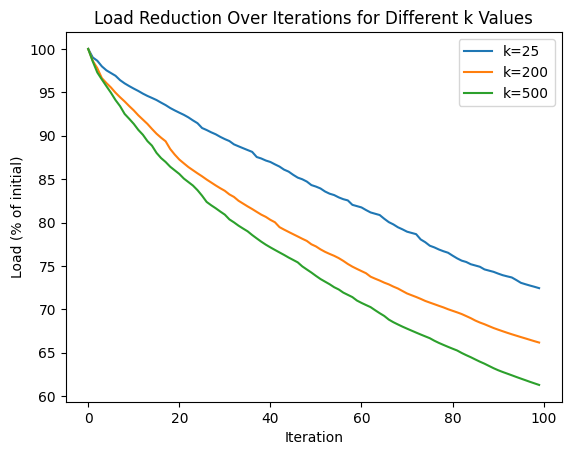

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'results' dict exists: mapping k -> list of load sums by iteration
# E.g., results = {25: [...], 50: [...], 75: [...], 100: [...]}

plt.figure()
for k, loads in sorted(results.items()):
    # Convert to percentage relative to the first iteration
    baseline = loads[0]
    pct = [100 * l / baseline for l in loads]
    plt.plot(pct, label=f'k={k}')

plt.xlabel('Iteration')
plt.ylabel('Load (% of initial)')
plt.title('Load Reduction Over Iterations for Different k Values')
plt.legend()
plt.show()


In [16]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# Make sure subg, D_euc, and loads_per_pair are defined in the session
D_geo = np.array(subg.distances(weights='weight'))
loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)

# Choose a max k to iterate over (one by one)
max_k = 2000  # adjust as needed, but be wary of performance

results = []
for k in tqdm(range(1, max_k + 1, 50)):
    us, vs, ws, iu, ju, old_geo = select_topk_stretch(D_geo, D_euc, k)
    D_u, D_v = compute_candidate_endpoints(D_geo, us, vs, ws)
    best_via = compute_best_via(D_u, D_v, ws, iu, ju)
    load_reduction = compute_load_reduction(best_via, old_geo, loads_per_pair)

    idx = int(np.argmax(load_reduction))
    results.append({
        'k': k,
        'best_pair': f"({int(us[idx])}, {int(vs[idx])})",
        'predicted_drop': load_reduction[idx]
    })

df = pd.DataFrame(results)


100%|██████████| 40/40 [02:48<00:00,  4.22s/it]


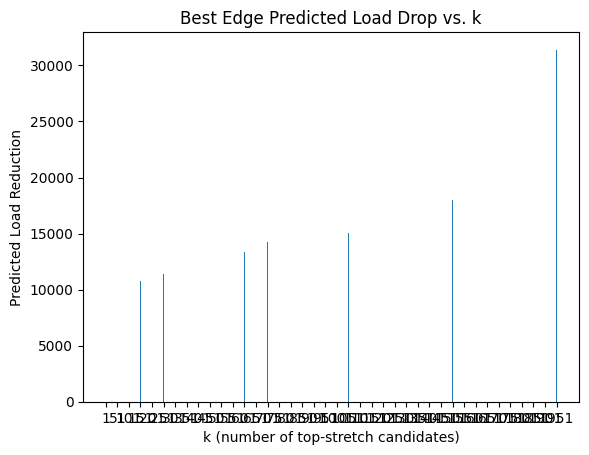

In [17]:
import matplotlib.pyplot as plt

# Assuming 'df' is a pandas DataFrame with columns 'k' and 'predicted_drop'
# e.g., df = pd.DataFrame(results) where results is a list of dicts with keys 'k' and 'predicted_drop'

plt.figure()
plt.bar(df['k'], df['predicted_drop'])
plt.xlabel('k (number of top-stretch candidates)')
plt.ylabel('Predicted Load Reduction')
plt.title('Best Edge Predicted Load Drop vs. k')
plt.xticks(df['k'])
plt.show()


In [14]:
import numpy as np

def compute_fiedler_vector(subg):
    """
    Compute the Fiedler (second-smallest) eigenvector of the graph Laplacian for igraph graph `subg`.
    Returns:
      - v2: numpy array of length n, the Fiedler vector.
    """
    # 1) Build adjacency matrix A
    A = np.array(subg.get_adjacency().data, dtype=float)
    # 2) Degree matrix D
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    # 3) Laplacian L = D - A
    L = D - A
    # 4) Compute eigenvalues/eigenvectors
    # Since L is symmetric, use eigh
    vals, vecs = np.linalg.eigh(L)
    # 5) Sort eigenvalues in ascending order
    idx = np.argsort(vals)
    # 6) The Fiedler vector is the eigenvector corresponding to the second smallest eigenvalue
    fiedler_idx = idx[1]
    v2 = vecs[:, fiedler_idx]
    return v2

# Example usage:
v2 = compute_fiedler_vector(subg)
print("First few entries of the Fiedler vector:", v2[:10])


First few entries of the Fiedler vector: [ 0.00735379  0.01841793 -0.00240274 -0.00197717 -0.06379387 -0.00155191
  0.00644616 -0.00297531  0.01827864  0.01160838]


In [17]:
import numpy as np

# 1) Compute Fiedler vector
v2 = compute_fiedler_vector(subg)

# 2) Find the pair of nodes maximizing |v2[u] - v2[v]|
u = int(np.argmax(v2))
v = int(np.argmin(v2))

print(f"Chosen endpoints by Fiedler gap: ({u}, {v})")

# 3) Prepare data for load-reduction computation on tracked pairs
loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)
pairs = list(pair_paths.keys())
P_tr = len(pairs)

# Build flattened tracked indices
iu_tr = np.array([i for (i, j) in pairs], dtype=int)
ju_tr = np.array([j for (i, j) in pairs], dtype=int)

# 4) Compute original geodesic distances
D_geo = np.array(subg.distances(weights='weight'))
old_geo_tr = D_geo[iu_tr, ju_tr]

# 5) Compute via-distances for the new edge (u,v)
w_uv = D_euc[u, v]
D_u = D_geo[u]  # distances from u to all nodes
D_v = D_geo[v]  # distances from v to all nodes

via_uv = D_u[iu_tr] + w_uv + D_v[ju_tr]
via_vu = D_v[iu_tr] + w_uv + D_u[ju_tr]
best_via = np.minimum(via_uv, via_vu)

# 6) Compute per-pair delta and total load reduction
frac = np.clip((old_geo_tr - best_via) / old_geo_tr, a_min=0, a_max=None)
delta_pair = loads_per_pair * frac
predicted_drop = delta_pair.sum()

print(f"Predicted total load reduction by adding edge ({u}, {v}): {predicted_drop:.6f}")


Chosen endpoints by Fiedler gap: (138, 100)
Predicted total load reduction by adding edge (138, 100): 7086.451488


In [18]:
import numpy as np

# Assume subg, D_euc are already defined.

# 1) Compute a clustering assignments array using a linear-time method
# For example, label propagation (approximately O(m))
membership = np.array(subg.community_label_propagation(weights=subg.es['weight']).membership)

# 2) Precompute full upper-triangle indices once
n = subg.vcount()
iu, ju = np.triu_indices(n, k=1)

# 3) Filter pairs that are in different clusters
diff_cluster_mask = membership[iu] != membership[ju]
iu_diff = iu[diff_cluster_mask]
ju_diff = ju[diff_cluster_mask]

# 4) Compute stretch ratio for these inter-cluster pairs
old_geo = np.array(subg.distances(weights='weight'))  # full APSP if not cached
old_geo_pairs = old_geo[iu_diff, ju_diff]
old_euc_pairs = D_euc[iu_diff, ju_diff] + 1e-12
stretch_ratio = old_geo_pairs / old_euc_pairs

# 5) Pick top-k by stretch among inter-cluster edges
k = 100
top_idx = np.argpartition(-stretch_ratio, k)[:k]
us = iu_diff[top_idx]
vs = ju_diff[top_idx]

# Now (us, vs) are your k most stretched inter-cluster candidate edges
print("Top-k inter-cluster candidates:", list(zip(us, vs)))


Top-k inter-cluster candidates: [(np.int64(138), np.int64(139)), (np.int64(139), np.int64(363)), (np.int64(73), np.int64(103)), (np.int64(46), np.int64(73)), (np.int64(47), np.int64(139)), (np.int64(8), np.int64(139)), (np.int64(100), np.int64(139)), (np.int64(139), np.int64(303)), (np.int64(100), np.int64(248)), (np.int64(100), np.int64(212)), (np.int64(17), np.int64(73)), (np.int64(23), np.int64(139)), (np.int64(139), np.int64(367)), (np.int64(191), np.int64(212)), (np.int64(65), np.int64(100)), (np.int64(139), np.int64(341)), (np.int64(23), np.int64(65)), (np.int64(43), np.int64(139)), (np.int64(17), np.int64(34)), (np.int64(106), np.int64(139)), (np.int64(97), np.int64(100)), (np.int64(73), np.int64(322)), (np.int64(23), np.int64(73)), (np.int64(119), np.int64(139)), (np.int64(23), np.int64(212)), (np.int64(38), np.int64(73)), (np.int64(23), np.int64(248)), (np.int64(73), np.int64(100)), (np.int64(138), np.int64(183)), (np.int64(114), np.int64(139)), (np.int64(84), np.int64(100)), 

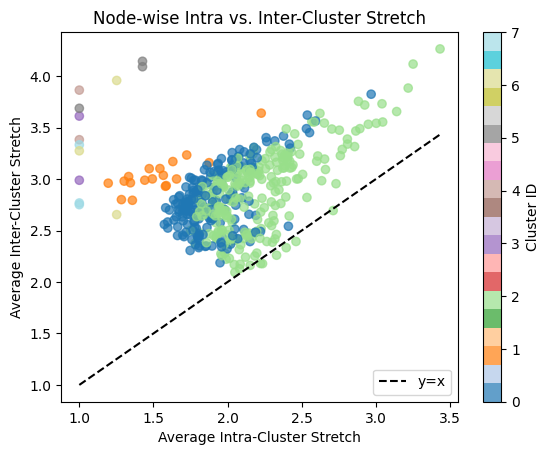

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Assume subg, D_euc, and membership are defined in the environment
# membership: array of length n, cluster label per node

# Compute current geodesic distances
D_geo = np.array(subg.distances(weights='weight'))

n = subg.vcount()
eps = 1e-12

avg_intra = np.zeros(n)
avg_inter = np.zeros(n)

for i in range(n):
    same = np.where((membership == membership[i]) & (np.arange(n) != i))[0]
    diff = np.where(membership != membership[i])[0]
    # Compute stretch ratios
    ratios = D_geo[i] / (D_euc[i] + eps)
    avg_intra[i] = ratios[same].mean() if same.size > 0 else np.nan
    avg_inter[i] = ratios[diff].mean() if diff.size > 0 else np.nan

# Scatter plot
plt.figure()
scatter = plt.scatter(avg_intra, avg_inter, c=membership, cmap='tab20', alpha=0.7)
plt.plot([avg_intra.min(), avg_intra.max()],
         [avg_intra.min(), avg_intra.max()], 'k--', label='y=x')
plt.xlabel('Average Intra-Cluster Stretch')
plt.ylabel('Average Inter-Cluster Stretch')
plt.title('Node-wise Intra vs. Inter-Cluster Stretch')
plt.legend()
plt.colorbar(scatter, label='Cluster ID')
plt.show()
